In [1]:
import pandas as pd 

listings = pd.read_csv('../data_raw/listings.csv')
calendar = pd.read_csv('../data_raw/calendar.csv')
reviews = pd.read_csv('../data_raw/reviews.csv')

listings.head()

C:\Users\cebal\AppData\Local\Temp\ipykernel_12376\1774549374.py:3: DtypeWarning: Columns (61,62,95) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv('../data_raw/listings.csv')


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11508,https://www.airbnb.com/rooms/11508,20200426042522,2020-04-26,Amazing Luxurious Apt-Palermo Soho,NaN,LUXURIOUS NEW APT: 1 BDRM- POOL/ GYM/ SPA/ 24-...,LUXURIOUS NEW APT: 1 BDRM- POOL/ GYM/ SPA/ 24-...,none,AREA: PALERMO SOHO Minutes walking distance fr...,...,f,f,strict_14_with_grace_period,f,f,1,1,0,0,0.27
1,12463,https://www.airbnb.com/rooms/12463,20200426042522,2020-04-26,Room in Recoleta - awesome location,My apartment is centrally located in Recoleta ...,This is a very comfortable pull-out sofa in th...,My apartment is centrally located in Recoleta ...,none,It's near the school of medicine so the street...,...,f,f,moderate,f,f,1,0,1,0,0.16
2,13095,https://www.airbnb.com/rooms/13095,20200426042522,2020-04-26,Standard Room at Palermo Viejo B&B,Palermo Viejo B&B is a typical home in one of ...,Standard room : Palermo Viejo Bed & Breakfast ...,Palermo Viejo B&B is a typical home in one of ...,none,NaN,...,f,f,strict_14_with_grace_period,f,f,7,0,7,0,0.06
3,13096,https://www.airbnb.com/rooms/13096,20200426042522,2020-04-26,Standard Room in Palermo Viejo B&B,Palermo Viejo B&B is a typical home in one of ...,Palermo Viejo Bed & Breakfast is located in a ...,Palermo Viejo B&B is a typical home in one of ...,none,NaN,...,f,f,strict_14_with_grace_period,f,f,7,0,7,0,NaN
4,13097,https://www.airbnb.com/rooms/13097,20200426042522,2020-04-26,Standard Room at Palermo Viejo B&B,Palermo Viejo B&B is a typical home in one of ...,Palermo Viejo Bed & Breakfast is located in a ...,Palermo Viejo B&B is a typical home in one of ...,none,NaN,...,f,f,strict_14_with_grace_period,f,f,7,0,7,0,1.89


In [2]:
print(listings.shape)
print(calendar.shape)
print(reviews.shape)


(23729, 106)
(8661286, 7)
(387099, 6)


In [3]:
listings.info()
calendar.info()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23729 entries, 0 to 23728
Columns: 106 entries, id to reviews_per_month
dtypes: float64(23), int64(21), object(62)
memory usage: 19.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8661286 entries, 0 to 8661285
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  object 
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 462.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387099 entries, 0 to 387098
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     387099 non-null  int64 
 1   id             387099 non-null  int64 
 2   date           387099 non-null  object
 3   reviewer_id    387099 non-null  int64 
 

In [4]:
listings.isnull().sum().sort_values(ascending=False).head(20)

thumbnail_url                   23729
medium_url                      23729
neighbourhood_group_cleansed    23729
xl_picture_url                  23729
license                         23729
jurisdiction_names              23722
square_feet                     23346
weekly_price                    21188
monthly_price                   21151
notes                           16007
access                          13525
house_rules                     13078
host_about                      10000
interaction                      9824
transit                          9221
security_deposit                 8195
neighborhood_overview            7665
space                            7194
review_scores_value              6909
review_scores_communication      6908
dtype: int64

In [5]:
calendar.isnull().sum().sort_values(ascending=False)

maximum_nights    105
minimum_nights    105
listing_id          0
available           0
date                0
adjusted_price      0
price               0
dtype: int64

In [6]:
reviews.isnull().sum().sort_values(ascending=False)

comments         176
listing_id         0
id                 0
date               0
reviewer_id        0
reviewer_name      0
dtype: int64

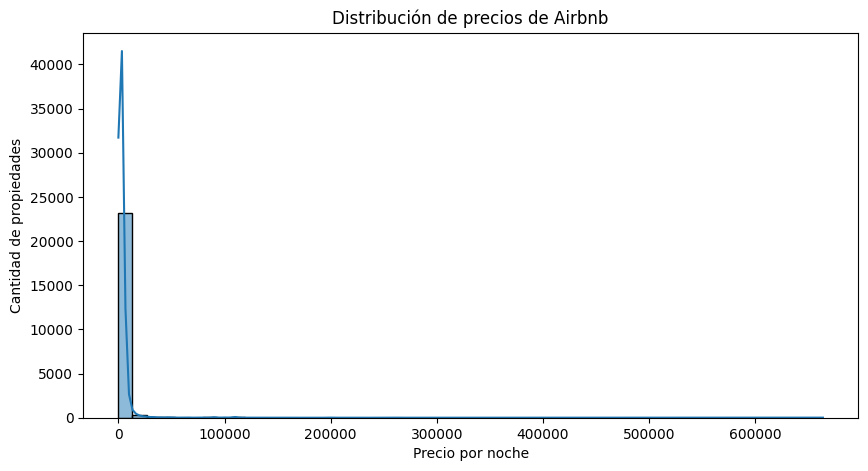

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

listings['price_numeric'] = listings['price'].replace(regex=r'[\$,]', value='').astype(float)

plt.figure(figsize=(10,5))
sns.histplot(listings['price_numeric'], bins=50, kde=True)

plt.title('Distribución de precios de Airbnb')
plt.xlabel('Precio por noche')
plt.ylabel('Cantidad de propiedades')

plt.show()

plt.show()

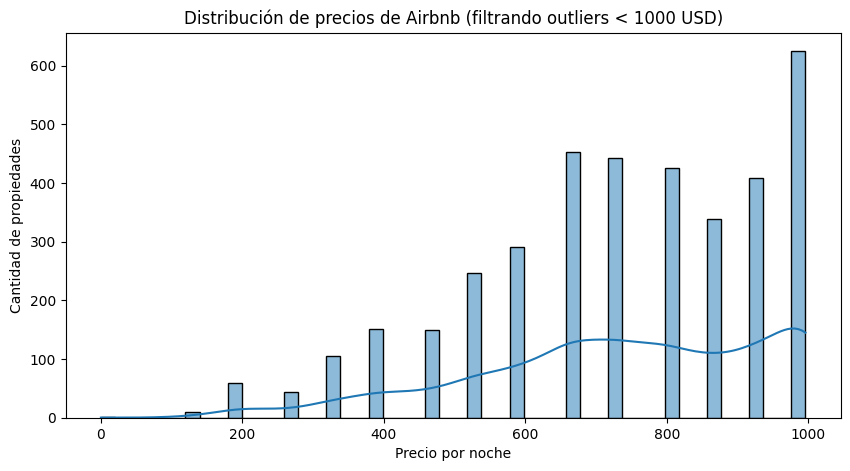

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(listings[listings['price_numeric'] < 1000]['price_numeric'], bins=50, kde=True)
plt.title('Distribución de precios de Airbnb (filtrando outliers < 1000 USD)')
plt.xlabel('Precio por noche')
plt.ylabel('Cantidad de propiedades')
plt.show()

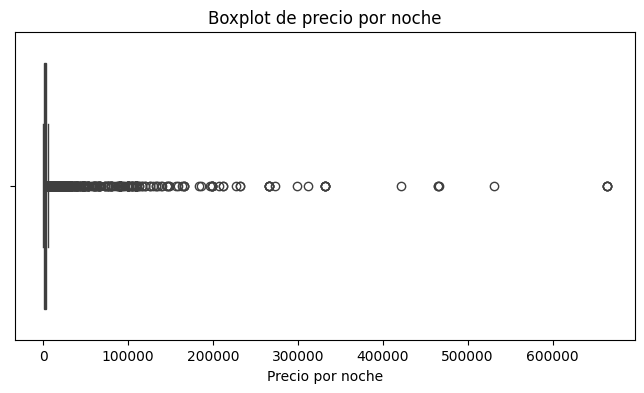

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x=listings['price_numeric'])
plt.title('Boxplot de precio por noche')
plt.xlabel('Precio por noche')
plt.show()

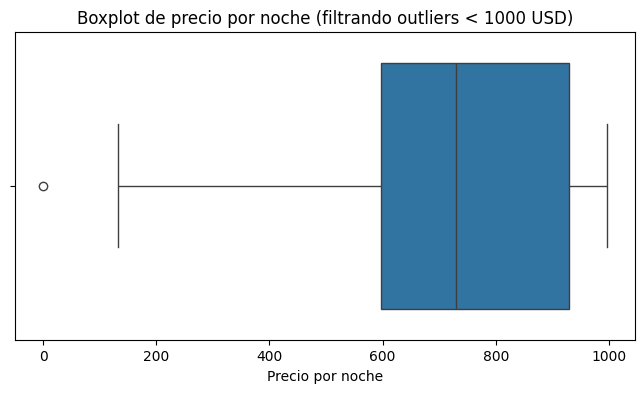

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(x=listings[listings['price_numeric'] < 1000]['price_numeric'])
plt.title('Boxplot de precio por noche (filtrando outliers < 1000 USD)')
plt.xlabel('Precio por noche')
plt.show()


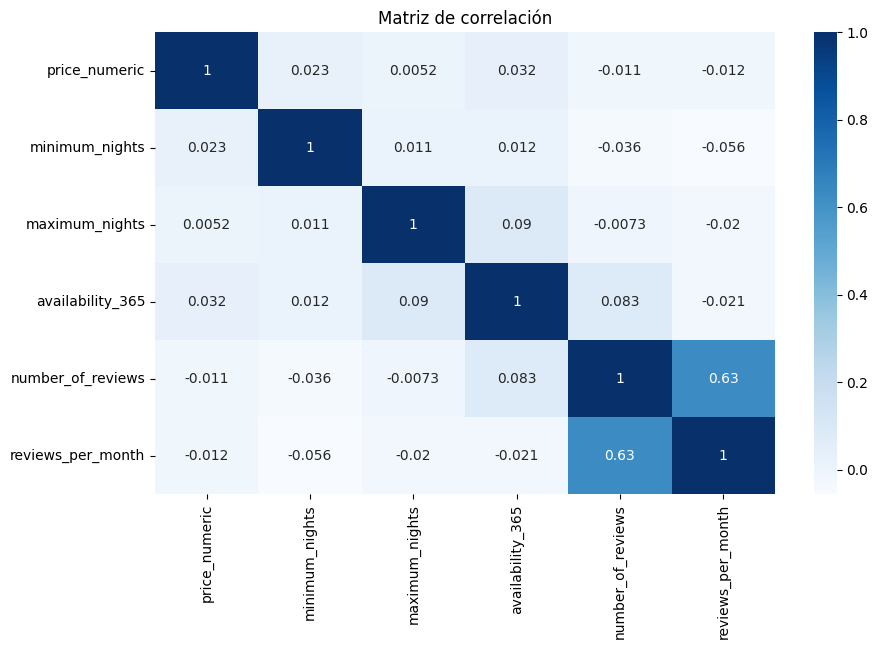

In [11]:
numeric_cols = ['price_numeric', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month']

subset = listings[numeric_cols].dropna()

plt.figure(figsize=(10,6))
sns.heatmap(subset.corr(), annot=True, cmap='Blues')
plt.title('Matriz de correlación')
plt.show()

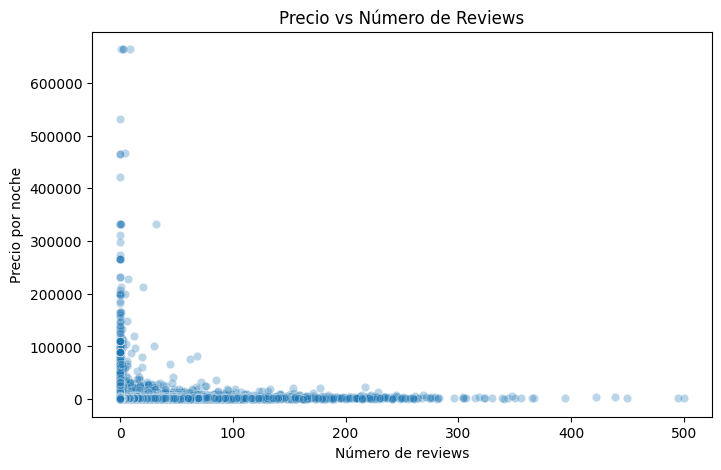

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=listings, x='number_of_reviews', y='price_numeric', alpha=0.3)
plt.title('Precio vs Número de Reviews')
plt.xlabel('Número de reviews')
plt.ylabel('Precio por noche')
plt.show()

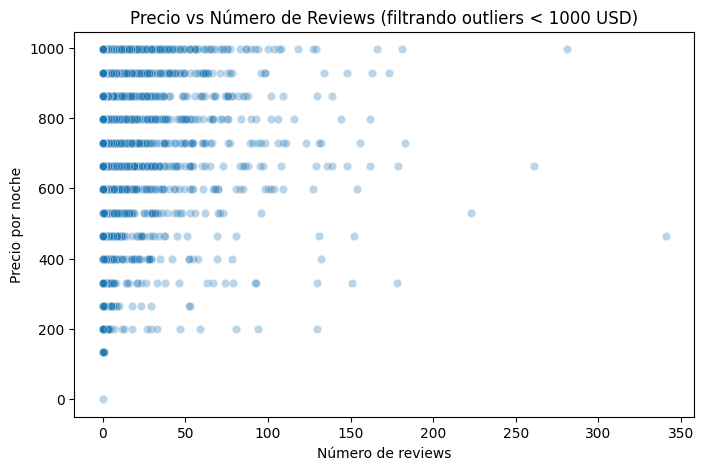

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=listings[listings['price_numeric'] < 1000],
    x='number_of_reviews',
    y='price_numeric',
    alpha=0.3
)
plt.title('Precio vs Número de Reviews (filtrando outliers < 1000 USD)')
plt.xlabel('Número de reviews')
plt.ylabel('Precio por noche')
plt.show()

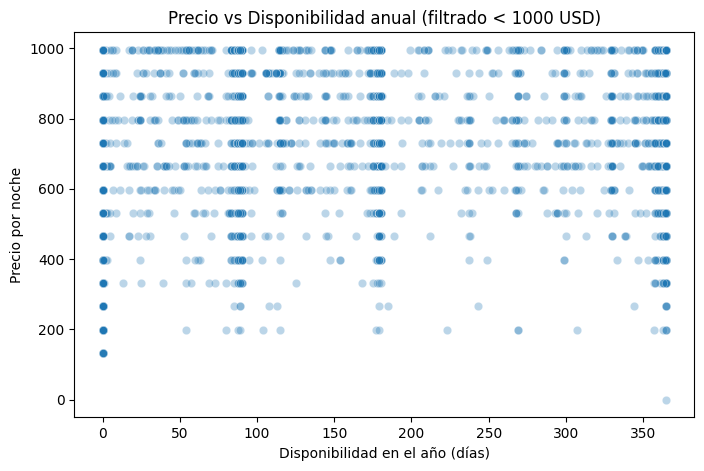

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=listings[listings['price_numeric'] < 1000],
    x='availability_365',
    y='price_numeric',
    alpha=0.3
)
plt.title('Precio vs Disponibilidad anual (filtrado < 1000 USD)')
plt.xlabel('Disponibilidad en el año (días)')
plt.ylabel('Precio por noche')
plt.show()